# Fingerprint of El Nino on predictors and their indications with respect to skipjack adult biomass

### imports

In [1]:
import sys
import os

import numpy as np
import pandas as pd
import xarray as xr
import scipy as sci
import h5py as h5

import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean.cm as cmo
from cmocean.tools import lighten

# regridding package
import xesmf as xe


# print versions of packages
print("python version =",sys.version[:5])
print("numpy version =", np.__version__)
print("pandas version =", pd.__version__)
print("xarray version =", xr.__version__)
print("scipy version =", sci.__version__)
print("h5py version =", h5.__version__)
print("matplotlib version =", sys.modules[plt.__package__].__version__)
print("cmocean version =", sys.modules[cmo.__package__].__version__)
print("cartopy version =", sys.modules[ccrs.__package__].__version__)
print("xesmf version =", xe.__version__)


wrkdir = "/g/data/es60/SEAPODYM/pearse_GAMs"
os.chdir(wrkdir)


python version = 3.10.
numpy version = 2.2.5
pandas version = 2.3.3
xarray version = 2025.4.0
scipy version = 1.15.3
h5py version = 3.15.1
matplotlib version = 3.10.6
cmocean version = v3.0.3
cartopy version = 0.24.1
xesmf version = 0.8.10


### Dask client

In [2]:
from dask.distributed import Client, LocalCluster

# Rule of thumb here:
# - 56 workers × 1 thread each (good isolation for NumPy/xarray)
# - ~8 GB per worker → 56 * 8 = 448 GB (leaves headroom for OS, Jupyter, scheduler)
cluster = LocalCluster(
    n_workers=56,
    threads_per_worker=1,
    memory_limit="8GB",
    # Optional niceties:
    dashboard_address=":8787",   # or ":0" for random free port
    processes=True,
)

client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 56
Total threads: 56,Total memory: 417.23 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41415,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:42667,Total threads: 1
Dashboard: /proxy/40011/status,Memory: 7.45 GiB
Nanny: tcp://127.0.0.1:46583,


### Load the dataset with predictions and term effects of the most parsimonious GAM

In [4]:
%%time

df = pd.read_csv("./anomalous_values_GAM_FS5terms_WCPO.csv")
print(len(df))


1315600
CPU times: user 20.2 s, sys: 2.49 s, total: 22.6 s
Wall time: 16.5 s


### Convert the log transformed data used for training GAMs back to their original units

In [5]:
%%time

def conv(y):
    x = y + 0.0
    x = np.sign(y) * (10**(np.abs(y)) - 1.0)
    return x

df['adult_biomass_pred'] = conv(df['adult_biomassTF_pred_FS5'])*1e3  # convert from Mt per km2 to Kt per km2
df['adult_biomass_pred_SST'] = conv(df['eff_sst'])*1e3
df['adult_biomass_pred_TL1'] = conv(df['eff_T_L1'])*1e3
df['adult_biomass_pred_UL3'] = conv(df['eff_U_L3'])*1e3
df['adult_biomass_pred_OL2'] = conv(df['eff_O2_L2'])*1e3
df['adult_biomass_pred_ZEU'] = conv(df['eff_zeu'])*1e3
df['adult_biomass_pred_TL2'] = conv(df['eff_T_L2'])*1e3


CPU times: user 1.03 s, sys: 65.1 ms, total: 1.09 s
Wall time: 812 ms


### Make an xarray for plotting

In [6]:
%%time

ds = (
    df
    .set_index(['lon', 'lat', 'season_year', 'season'])
    .to_xarray()
)
ds = ds.assign_coords(season_year=np.arange(1960,2024,1))
ds

CPU times: user 2.87 s, sys: 804 ms, total: 3.67 s
Wall time: 2.55 s


<xarray.Dataset> Size: 745MB
Dimensions:                   (lon: 130, lat: 40, season_year: 64, season: 4)
Coordinates:
  * lon                       (lon) float64 1kB 120.5 121.5 ... 248.5 249.5
  * lat                       (lat) float64 320B -19.5 -18.5 -17.5 ... 18.5 19.5
  * season                    (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
  * season_year               (season_year) int64 512B 1960 1961 ... 2022 2023
Data variables: (12/70)
    lat.1                     (lon, lat, season_year, season) float64 11MB -1...
    lon.1                     (lon, lat, season_year, season) float64 11MB 12...
    adult_biomass             (lon, lat, season_year, season) float64 11MB 0....
    young_biomass             (lon, lat, season_year, season) float64 11MB -0...
    juvenile_biomass          (lon, lat, season_year, season) float64 11MB -1...
    larvae_biomass            (lon, lat, season_year, season) float64 11MB -0...
    ...                        ...
    adult_biomass_pred_SST    (lon, lat, season_year, season) float64 11MB na...
    adult_biomass_pred_TL1    (lon, lat, season_year, season) float64 11MB na...
    adult_biomass_pred_UL3    (lon, lat, season_year, season) float64 11MB na...
    adult_biomass_pred_OL2    (lon, lat, season_year, season) float64 11MB na...
    adult_biomass_pred_ZEU    (lon, lat, season_year, season) float64 11MB na...
    adult_biomass_pred_TL2    (lon, lat, season_year, season) float64 11MB na...

### Visualise the change in adult biomass associated with the 2016 El Nino

In [7]:
%%time

lons = ds.coords['lon']
lats = ds.coords['lat']


CPU times: user 92 μs, sys: 35 μs, total: 127 μs
Wall time: 147 μs


/g/data/es60/pjb581/miniforge3/envs/pyEMD_env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


CPU times: user 16.9 s, sys: 2.97 s, total: 19.9 s
Wall time: 18 s


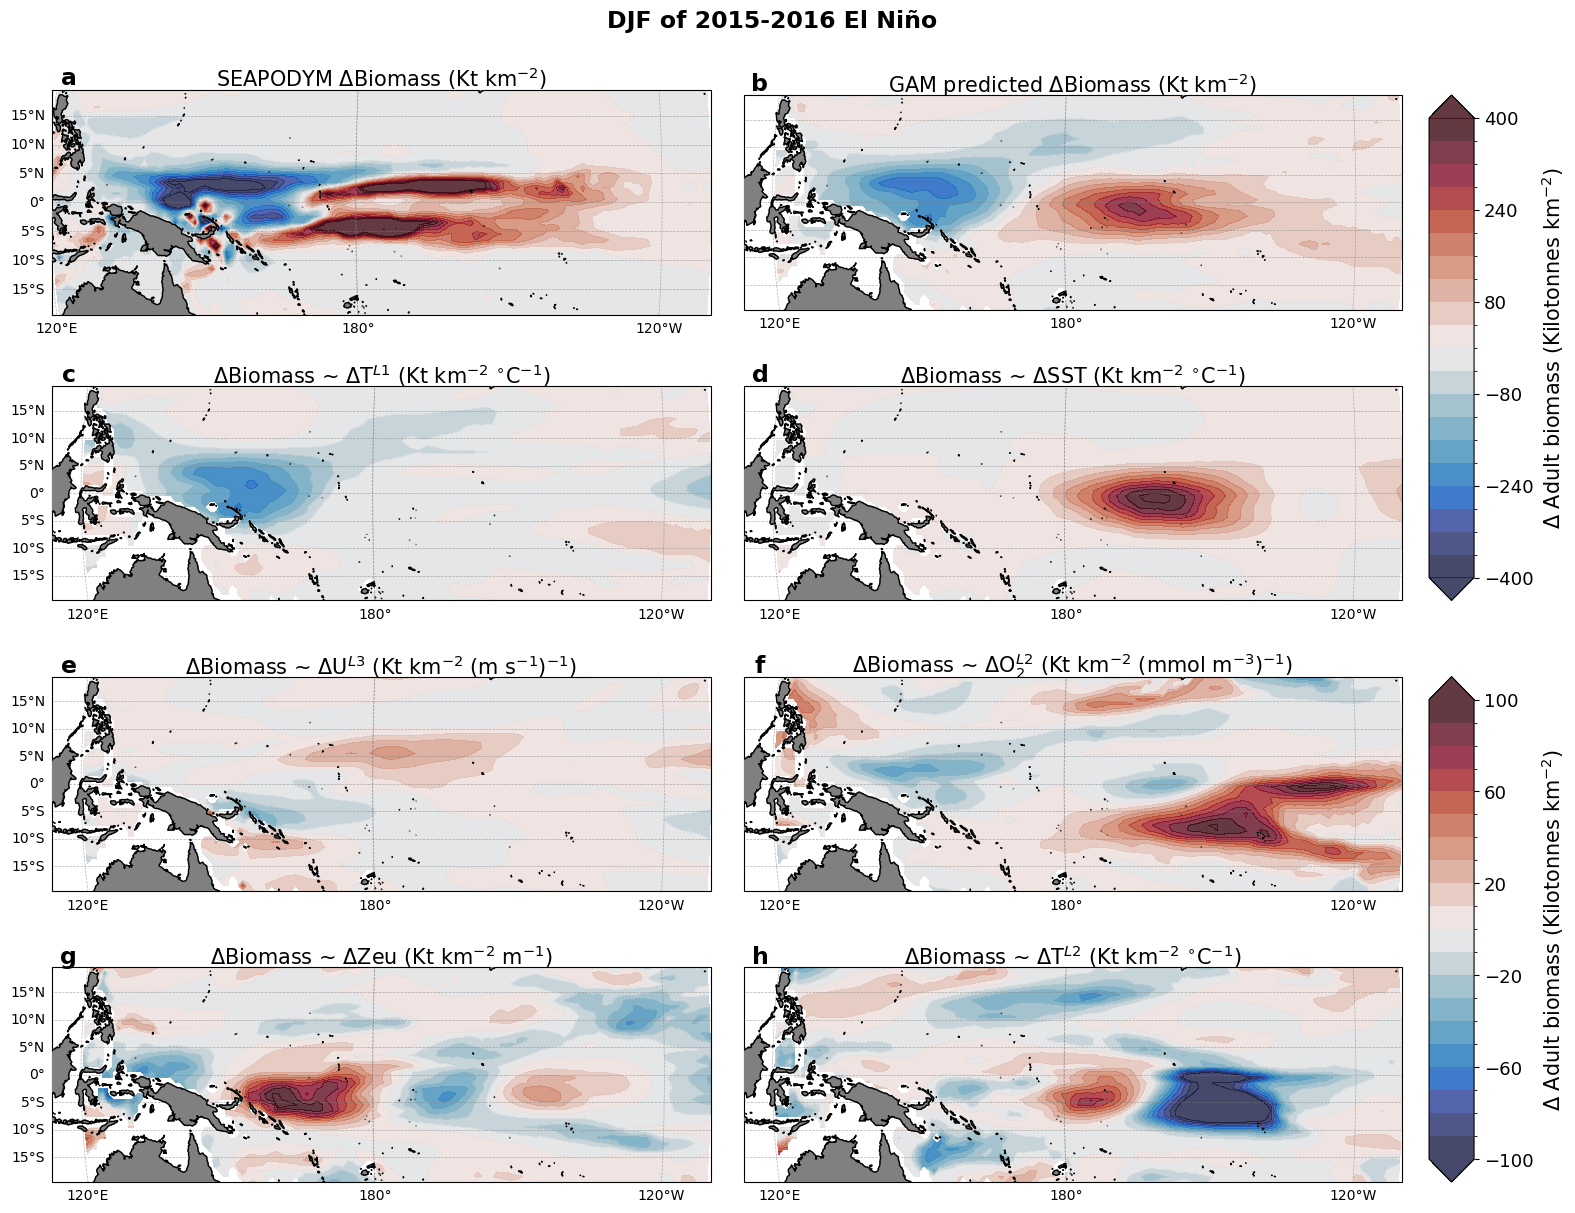

In [8]:
%%time

proj = ccrs.Robinson(central_longitude=205)

fstic = 13
fslab = 15

colmap = lighten(cmo.balance, 0.8)
levs1 = np.arange(-10,11,1)*40
norm1 = mcolors.BoundaryNorm(levs1, ncolors=256)
levs2 = np.arange(-10,11,1)*10
norm2 = mcolors.BoundaryNorm(levs2, ncolors=256)

fig = plt.figure(figsize=(18,13))
gs = GridSpec(4,2)

ax1 = plt.subplot(gs[0,0], projection=proj)
ax2 = plt.subplot(gs[0,1], projection=proj)
ax3 = plt.subplot(gs[1,0], projection=proj)
ax4 = plt.subplot(gs[1,1], projection=proj)
ax5 = plt.subplot(gs[2,0], projection=proj)
ax6 = plt.subplot(gs[2,1], projection=proj)
ax7 = plt.subplot(gs[3,0], projection=proj)
ax8 = plt.subplot(gs[3,1], projection=proj)

p1 = ax1.contourf(lons, lats, ds['adult_biomass'].sel(season_year=2016, season="DJF").T*1e3, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm1, levels=levs1, extend='both')
p2 = ax2.contourf(lons, lats, ds['adult_biomass_pred'].sel(season_year=2016, season="DJF").T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm1, levels=levs1, extend='both')
p3 = ax3.contourf(lons, lats, ds['adult_biomass_pred_TL1'].sel(season_year=2016, season="DJF").T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm1, levels=levs1, extend='both')
p4 = ax4.contourf(lons, lats, ds['adult_biomass_pred_SST'].sel(season_year=2016, season="DJF").T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm1, levels=levs1, extend='both')
p5 = ax5.contourf(lons, lats, ds['adult_biomass_pred_UL3'].sel(season_year=2016, season="DJF").T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm2, levels=levs2, extend='both')
p6 = ax6.contourf(lons, lats, ds['adult_biomass_pred_OL2'].sel(season_year=2016, season="DJF").T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm2, levels=levs2, extend='both')
p7 = ax7.contourf(lons, lats, ds['adult_biomass_pred_ZEU'].sel(season_year=2016, season="DJF").T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm2, levels=levs2, extend='both')
p8 = ax8.contourf(lons, lats, ds['adult_biomass_pred_TL2'].sel(season_year=2016, season="DJF").T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm2, levels=levs2, extend='both')

ax1.add_feature(cfeature.LAND, color='grey', zorder=3)
ax1.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax2.add_feature(cfeature.LAND, color='grey', zorder=3)
ax2.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax3.add_feature(cfeature.LAND, color='grey', zorder=3)
ax3.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax4.add_feature(cfeature.LAND, color='grey', zorder=3)
ax4.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax5.add_feature(cfeature.LAND, color='grey', zorder=3)
ax5.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax6.add_feature(cfeature.LAND, color='grey', zorder=3)
ax6.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax7.add_feature(cfeature.LAND, color='grey', zorder=3)
ax7.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax8.add_feature(cfeature.LAND, color='grey', zorder=3)
ax8.add_feature(cfeature.COASTLINE, color='k', zorder=4)

gl1 = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl2 = ax2.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl3 = ax3.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl4 = ax4.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl5 = ax5.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl6 = ax6.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl7 = ax7.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl8 = ax8.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')

gl1.top_labels = False; gl1.right_labels = False
gl2.top_labels = False; gl2.right_labels = False; gl2.left_labels = False
gl3.top_labels = False; gl3.right_labels = False
gl4.top_labels = False; gl4.right_labels = False; gl4.left_labels = False
gl5.top_labels = False; gl5.right_labels = False
gl6.top_labels = False; gl6.right_labels = False; gl6.left_labels = False
gl7.top_labels = False; gl7.right_labels = False
gl8.top_labels = False; gl8.right_labels = False; gl8.left_labels = False

xx = 0.5; yy=1.05
plt.text(xx,yy,"SEAPODYM $\Delta$Biomass (Kt km$^{-2}$)", fontsize=fslab, ha='center', va='center', transform=ax1.transAxes)
plt.text(xx,yy,"GAM predicted $\Delta$Biomass (Kt km$^{-2}$)", fontsize=fslab, ha='center', va='center', transform=ax2.transAxes)
plt.text(xx,yy,"$\Delta$Biomass ~ $\Delta$T$^{L1}$ (Kt km$^{-2}$ $^{\circ}$C$^{-1}$)", fontsize=fslab, ha='center', va='center', transform=ax3.transAxes)
plt.text(xx,yy,"$\Delta$Biomass ~ $\Delta$SST (Kt km$^{-2}$ $^{\circ}$C$^{-1}$)", fontsize=fslab, ha='center', va='center', transform=ax4.transAxes)
plt.text(xx,yy,"$\Delta$Biomass ~ $\Delta$U$^{L3}$ (Kt km$^{-2}$ (m s$^{-1}$)$^{-1}$)", fontsize=fslab, ha='center', va='center', transform=ax5.transAxes)
plt.text(xx,yy,"$\Delta$Biomass ~ $\Delta$O$_2^{L2}$ (Kt km$^{-2}$ (mmol m$^{-3}$)$^{-1}$)", fontsize=fslab, ha='center', va='center', transform=ax6.transAxes)
plt.text(xx,yy,"$\Delta$Biomass ~ $\Delta$Zeu (Kt km$^{-2}$ m$^{-1}$)", fontsize=fslab, ha='center', va='center', transform=ax7.transAxes)
plt.text(xx,yy,"$\Delta$Biomass ~ $\Delta$T$^{L2}$ (Kt km$^{-2}$ $^{\circ}$C$^{-1}$)", fontsize=fslab, ha='center', va='center', transform=ax8.transAxes)

plt.subplots_adjust(wspace=0.05, hspace=0.25, left=0.1, right=0.85, bottom=0.05, top=0.9)

pos2 = ax2.get_position()
pos4 = ax4.get_position()
pos6 = ax6.get_position()
pos8 = ax8.get_position()
cbax1 = fig.add_axes([pos4.x1+0.015,pos4.y0,0.025,pos2.y1-pos4.y0])
cbax2 = fig.add_axes([pos8.x1+0.015,pos8.y0,0.025,pos6.y1-pos8.y0])
cbar1 = plt.colorbar(p1, cax=cbax1, orientation='vertical', ticks=levs1[::4])
cbar1.ax.tick_params(labelsize=fstic)
cbar1.ax.set_ylabel("$\Delta$ Adult biomass (Kilotonnes km$^{-2}$)", fontsize=fslab)
cbar2 = plt.colorbar(p5, cax=cbax2, orientation='vertical', ticks=levs2[::4])
cbar2.ax.tick_params(labelsize=fstic)
cbar2.ax.set_ylabel("$\Delta$ Adult biomass (Kilotonnes km$^{-2}$)", fontsize=fslab)

xx = 0.025; yy = 1.05
plt.text(xx,yy,"a", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax1.transAxes)
plt.text(xx,yy,"b", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax2.transAxes)
plt.text(xx,yy,"c", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax3.transAxes)
plt.text(xx,yy,"d", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax4.transAxes)
plt.text(xx,yy,"e", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax5.transAxes)
plt.text(xx,yy,"f", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax6.transAxes)
plt.text(xx,yy,"g", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax7.transAxes)
plt.text(xx,yy,"h", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax8.transAxes)

plt.text(0.5,0.95, "DJF of 2015-2016 El Niño", transform=fig.transFigure, fontweight="bold", fontsize=fslab+2, va='center', ha='center')

fig.savefig("./figures/ElNino_fingerprint_predictor_effects.png", dpi=300, bbox_inches='tight')



### Look at the actual changes in the predictors at this time

/g/data/es60/pjb581/miniforge3/envs/pyEMD_env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


CPU times: user 9.06 s, sys: 1.28 s, total: 10.3 s
Wall time: 8.47 s


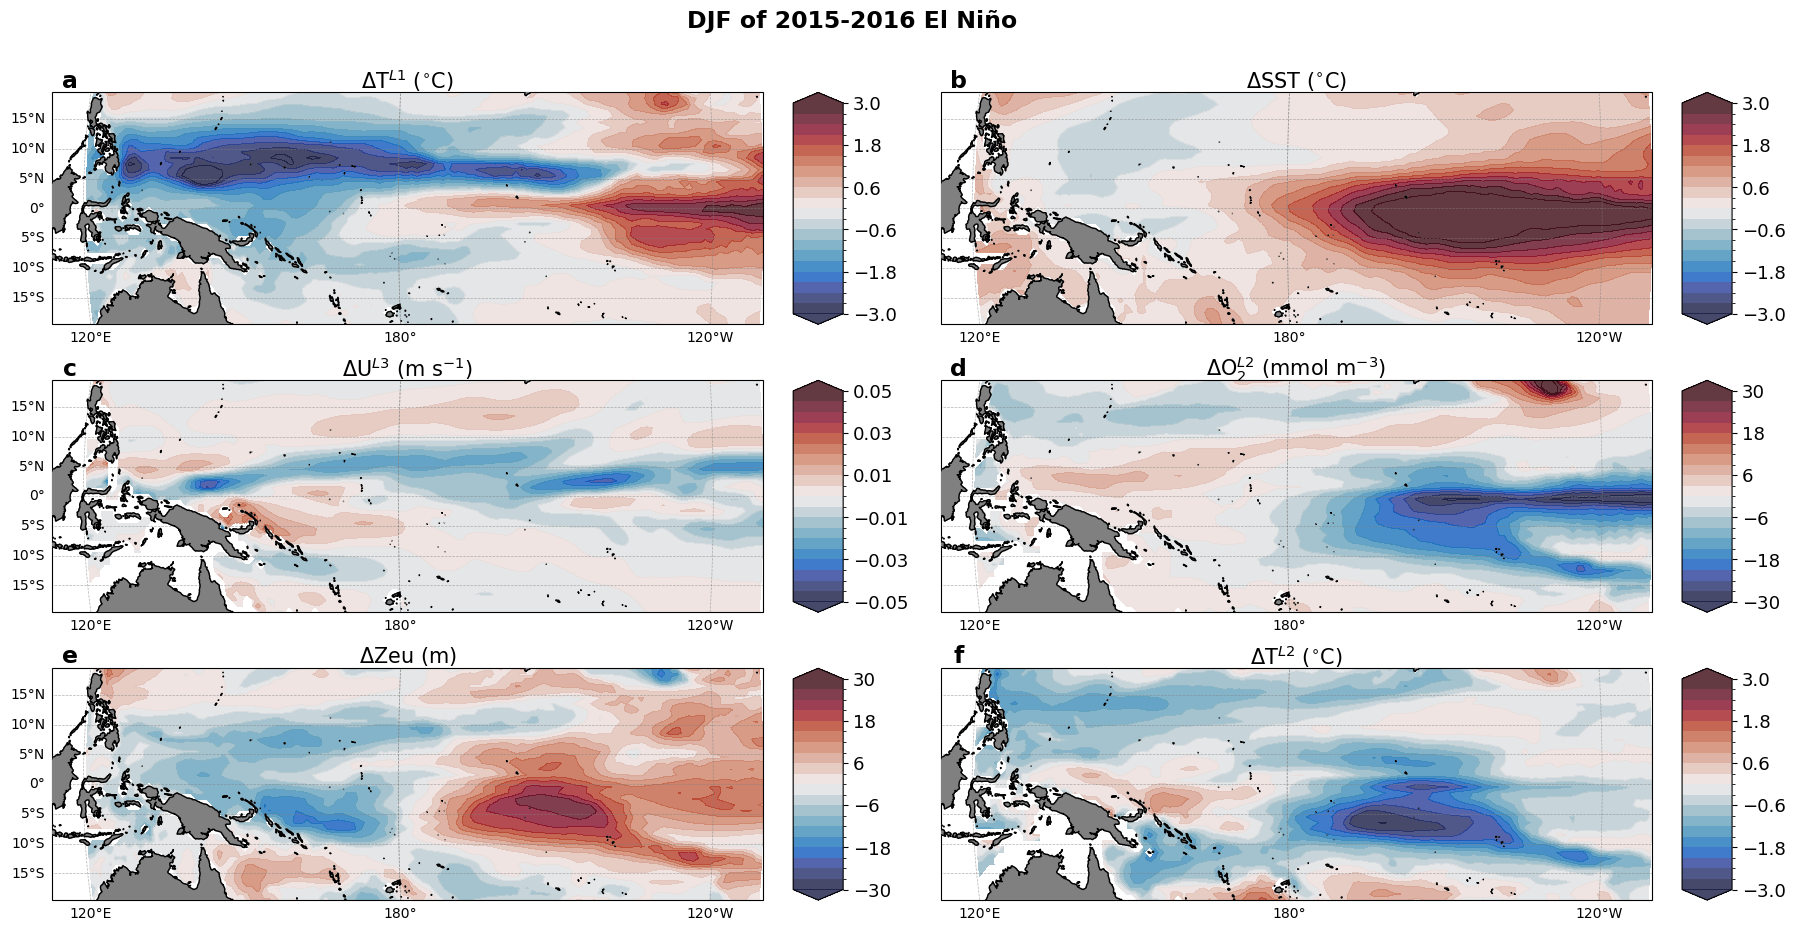

In [9]:
%%time

proj = ccrs.Robinson(central_longitude=205)

fstic = 13
fslab = 15

colmap = lighten(cmo.balance, 0.8)

levs1 = np.arange(-10,11,1)*0.3
levs2 = np.arange(-10,11,1)*0.3
levs3 = np.arange(-10,11,1)*0.005
levs4 = np.arange(-10,11,1)*3.0
levs5 = np.arange(-10,11,1)*3.0
levs6 = np.arange(-10,11,1)*0.3

norm1 = mcolors.BoundaryNorm(levs1, ncolors=256)
norm2 = mcolors.BoundaryNorm(levs2, ncolors=256)
norm3 = mcolors.BoundaryNorm(levs3, ncolors=256)
norm4 = mcolors.BoundaryNorm(levs4, ncolors=256)
norm5 = mcolors.BoundaryNorm(levs5, ncolors=256)
norm6 = mcolors.BoundaryNorm(levs6, ncolors=256)

fig = plt.figure(figsize=(20,10))
gs = GridSpec(3,2)

ax1 = plt.subplot(gs[0,0], projection=proj)
ax2 = plt.subplot(gs[0,1], projection=proj)
ax3 = plt.subplot(gs[1,0], projection=proj)
ax4 = plt.subplot(gs[1,1], projection=proj)
ax5 = plt.subplot(gs[2,0], projection=proj)
ax6 = plt.subplot(gs[2,1], projection=proj)

p1 = ax1.contourf(lons, lats, ds['T_L1'].sel(season_year=2016, season="DJF").T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm1, levels=levs1, extend='both')
p2 = ax2.contourf(lons, lats, ds['sst'].sel(season_year=2016, season="DJF").T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm2, levels=levs2, extend='both')
p3 = ax3.contourf(lons, lats, ds['U_L3'].sel(season_year=2016, season="DJF").T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm3, levels=levs3, extend='both')
p4 = ax4.contourf(lons, lats, ds['O2_L2'].sel(season_year=2016, season="DJF").T*44.661, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm4, levels=levs4, extend='both')
p5 = ax5.contourf(lons, lats, ds['zeu'].sel(season_year=2016, season="DJF").T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm5, levels=levs5, extend='both')
p6 = ax6.contourf(lons, lats, ds['T_L2'].sel(season_year=2016, season="DJF").T, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm6, levels=levs6, extend='both')

ax1.add_feature(cfeature.LAND, color='grey', zorder=3)
ax1.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax2.add_feature(cfeature.LAND, color='grey', zorder=3)
ax2.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax3.add_feature(cfeature.LAND, color='grey', zorder=3)
ax3.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax4.add_feature(cfeature.LAND, color='grey', zorder=3)
ax4.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax5.add_feature(cfeature.LAND, color='grey', zorder=3)
ax5.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax6.add_feature(cfeature.LAND, color='grey', zorder=3)
ax6.add_feature(cfeature.COASTLINE, color='k', zorder=4)

gl1 = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl2 = ax2.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl3 = ax3.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl4 = ax4.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl5 = ax5.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl6 = ax6.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')

gl1.top_labels = False; gl1.right_labels = False
gl2.top_labels = False; gl2.right_labels = False; gl2.left_labels = False
gl3.top_labels = False; gl3.right_labels = False
gl4.top_labels = False; gl4.right_labels = False; gl4.left_labels = False
gl5.top_labels = False; gl5.right_labels = False
gl6.top_labels = False; gl6.right_labels = False; gl6.left_labels = False

xx = 0.5; yy=1.05
plt.text(xx,yy,"$\Delta$T$^{L1}$ ($^{\circ}$C)", fontsize=fslab, ha='center', va='center', transform=ax1.transAxes)
plt.text(xx,yy,"$\Delta$SST ($^{\circ}$C)", fontsize=fslab, ha='center', va='center', transform=ax2.transAxes)
plt.text(xx,yy,"$\Delta$U$^{L3}$ (m s$^{-1}$)", fontsize=fslab, ha='center', va='center', transform=ax3.transAxes)
plt.text(xx,yy,"$\Delta$O$_2^{L2}$ (mmol m$^{-3}$)", fontsize=fslab, ha='center', va='center', transform=ax4.transAxes)
plt.text(xx,yy,"$\Delta$Zeu (m)", fontsize=fslab, ha='center', va='center', transform=ax5.transAxes)
plt.text(xx,yy,"$\Delta$T$^{L2}$ ($^{\circ}$C)", fontsize=fslab, ha='center', va='center', transform=ax6.transAxes)

plt.subplots_adjust(wspace=0.25, hspace=0.05, left=0.1, right=0.9, bottom=0.05, top=0.9)

pos1 = ax1.get_position()
pos2 = ax2.get_position()
pos3 = ax3.get_position()
pos4 = ax4.get_position()
pos5 = ax5.get_position()
pos6 = ax6.get_position()

cbax1 = fig.add_axes([pos1.x1+0.015,pos1.y0,0.025,pos1.y1-pos1.y0])
cbax2 = fig.add_axes([pos2.x1+0.015,pos2.y0,0.025,pos2.y1-pos2.y0])
cbax3 = fig.add_axes([pos3.x1+0.015,pos3.y0,0.025,pos3.y1-pos3.y0])
cbax4 = fig.add_axes([pos4.x1+0.015,pos4.y0,0.025,pos4.y1-pos4.y0])
cbax5 = fig.add_axes([pos5.x1+0.015,pos5.y0,0.025,pos5.y1-pos5.y0])
cbax6 = fig.add_axes([pos6.x1+0.015,pos6.y0,0.025,pos6.y1-pos6.y0])

cbar1 = plt.colorbar(p1, cax=cbax1, orientation='vertical', ticks=levs1[::4])
cbar1.ax.tick_params(labelsize=fstic)
#cbar1.ax.set_ylabel("($^{\circ}$C)", fontsize=fslab)

cbar2 = plt.colorbar(p2, cax=cbax2, orientation='vertical', ticks=levs2[::4])
cbar2.ax.tick_params(labelsize=fstic)
#cbar2.ax.set_ylabel("($^{\circ}$C)", fontsize=fslab)

cbar3 = plt.colorbar(p3, cax=cbax3, orientation='vertical', ticks=levs3[::4])
cbar3.ax.tick_params(labelsize=fstic)
#cbar3.ax.set_ylabel("($^{\circ}$C)", fontsize=fslab)

cbar4 = plt.colorbar(p4, cax=cbax4, orientation='vertical', ticks=levs4[::4])
cbar4.ax.tick_params(labelsize=fstic)
#cbar4.ax.set_ylabel("($^{\circ}$C)", fontsize=fslab)

cbar5 = plt.colorbar(p5, cax=cbax5, orientation='vertical', ticks=levs5[::4])
cbar5.ax.tick_params(labelsize=fstic)
#cbar5.ax.set_ylabel("($^{\circ}$C)", fontsize=fslab)

cbar6 = plt.colorbar(p6, cax=cbax6, orientation='vertical', ticks=levs6[::4])
cbar6.ax.tick_params(labelsize=fstic)
#cbar6.ax.set_ylabel("($^{\circ}$C)", fontsize=fslab)

plt.text(0.5,0.95, "DJF of 2015-2016 El Niño", transform=fig.transFigure, fontweight="bold", fontsize=fslab+2, va='center', ha='center')

xx = 0.025; yy = 1.05
plt.text(xx,yy,"a", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax1.transAxes)
plt.text(xx,yy,"b", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax2.transAxes)
plt.text(xx,yy,"c", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax3.transAxes)
plt.text(xx,yy,"d", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax4.transAxes)
plt.text(xx,yy,"e", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax5.transAxes)
plt.text(xx,yy,"f", fontweight="bold", fontsize=fslab+2, va='center', ha='center', transform=ax6.transAxes)

fig.savefig("./figures/ElNino_fingerprint_predictors.png", dpi=300, bbox_inches='tight')

